# Домашнее задание 3. Анализ данных

Задание выполнил(а):

    Евгений Денисов

# Часть I

Каждое задание в этой части оценивается в 0,15 баллов. Всего за выполнение этой части можно получить 2,55 балла.

In [183]:
import pandas as pd
import seaborn as sns
from scipy.stats import norm
import io
import numpy as np
import requests

In [184]:
DIABETS = 'https://raw.githubusercontent.com/evgpat/datasets/main/pima_indians_diabetes.csv'
BABIES = 'https://raw.githubusercontent.com/evgpat/datasets/main/babies_all.txt'

Будем работать с датасетом Pima Indian Diabetes - это набор данных из Национального института диабета, болезней органов пищеварения и почек. Целью набора данных является диагностическое прогнозирование наличия диабета у пациента. Несколько ограничений были наложены на выбор этих экземпляров из большой базы данных. В частности, все пациенты здесь - женщины в возрасте от 21 года, индийского происхождения.

In [185]:
response = requests.get(DIABETS, verify=False)
data = pd.read_csv(io.StringIO(response.text))
print(data.head())

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'raw.githubusercontent.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6    148.0           72.0           35.0      NaN  33.6   
1            1     85.0           66.0           29.0      NaN  26.6   
2            8    183.0           64.0            NaN      NaN  23.3   
3            1     89.0           66.0           23.0     94.0  28.1   
4            0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction  Age  Class  
0                     0.627   50      1  
1                     0.351   31      0  
2                     0.672   32      1  
3                     0.167   21      0  
4                     2.288   33      1  


Описание данных:

- __Pregnancies__ - данная единица отображает количество беременностей, единицы измерения - целые числа от 0 до N. Тип переменной - количественная, дискретная.
- __Glucose__ - данная единица отображает уровень глюкозы в крови, единицы измерения - целые числа. Тип переменной - количественная, дискретная.
- __BloodPressure__ - данная единица отображает артериальное давление, единицы измерения - миллиметры р/с, целые числа. Тип переменной - количественная, дискретная.
- __SkinThickness__ - данная единица отображает обхват трицепса в миллиметрах, целые числа. Тип переменной - количественная, дискретная.
- __Insulin__ - данная единица отображает уровень инсулина в крови, целые числа. Тип переменной - количественная, дискретная.
- __BMI__ - данная единица отображает индекс массы тела. Тип переменной - количественная, непрерывная.
- __DiabetesPedigreeFunction__ - данная единица отображает риск наследственного диабета в зависимости наличия диабета у родственников. Выражается десятичной дробью от 0 до 1. Тип переменной - количественная, непрерывная.
- __Age__ - данная единица отражает возраст в целых числах. Тип переменной - количественная, дискретная.
- __Class__ - данная единица отражает наличие диабета у субъекта, выражена 0(здоров) или 1(болен). Тип переменной - категориальная, бинарная.

## Задание 1

Как вы видите, в данных много пропусков (NaN). Любым способом посчитайте количество пропусков в каждом из столбцов.

Для тех переменных, в которых есть пропуски, выведите количество пропущенных значений в следующем формате:

**"В переменной {название переменной} {количество} пропущенных значений"**

In [186]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
list_of_columns = data.columns
my_dict = {}
for i in list_of_columns:
    n = data[i].isna().sum()
    if n > 0:
        my_dict[i] = n
for k,v in my_dict.items():
    print(f'В переменной {k} {v} пропущенных значений')

В переменной Glucose 5 пропущенных значений
В переменной BloodPressure 35 пропущенных значений
В переменной SkinThickness 227 пропущенных значений
В переменной Insulin 374 пропущенных значений
В переменной BMI 11 пропущенных значений


## Задание 2

Замените все пропуски дискретных признаков соответствующими медианами, непрерывных признаков - средними значениями.

In [187]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
list_of_columns = data.columns
for i in list_of_columns:
    med = data[i].median()
    mean = data[i].mean()
    if data[i].dtype == 'int64':
        data[i] = data[i].fillna(med)
    elif data[i].dtype == 'float64':
        data[i] = data[i].fillna(mean)

## Задание 3

Выведите основные статистики (минимум, максимум, среднее, дисперсию, квантили) для всех столбцов.

In [188]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Class
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,0.348958
std,3.369578,30.435949,12.096346,8.790942,85.021108,6.875151,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.202592,29.153420,155.548223,32.400000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,155.548223,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Задание 4

У скольких женщин строго старше 50 лет обнаружен диабет?

In [189]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
f = len(
        data[
            (data['Age'] > 50) 
            & (data['Class'] == 1)
            ]
        )
print(f'{f} женщин старше 50 лет имеют диабет')

38 женщин старше 50 лет имеют диабет


## Задание 5

Найдите трех женщин с наибольшими числом беременностей.

In [190]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
data_sorted = data.sort_values(by = 'Pregnancies', ascending = False)
data_sorted.head(3)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Class
159,17,163.0,72.0,41.0,114.0,40.9,0.817,47,1
88,15,136.0,70.0,32.0,110.0,37.1,0.153,43,1
298,14,100.0,78.0,25.0,184.0,36.6,0.412,46,1


## Задание 6

Сколько женщин возраста между 30 и 40 успело родить 3 или более детей?

In [191]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
f = len(
        data[
            (data['Age'] > 30) 
            & (data['Age'] < 40)
            & (data['Pregnancies'] >= 3)
            ]
        )
print(f'{f} женщин(ы) между 30 и 40 лет имеют 3 и более детей')

115 женщин(ы) между 30 и 40 лет имеют 3 и более детей


## Задание 7

Нормальным кровяным давлением будем считать давление в диапазоне [80-89]. У какого процента женщин давление нормальное?

In [192]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。

## Задание 8

У скольких женщин с признаками ожирения (BMI >= 30) давление выше среднего?

In [193]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
num = len(
        (data['BMI'] >= 30)
         & (data['BloodPressure'] > data['BloodPressure'].median())
        )
print(f'{num} женщин c признаками ожирения имеют давление выше среднего')

768 женщин c признаками ожирения имеют давление выше среднего


## Задание 9

Сравните средние значения для признаков __Glucose,	BloodPressure,	Insulin__ среди тех, у кого обнаружен диабет, и тех, у кого его нет.

In [194]:
# Glucose ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
compare = data[(data['Class'] == 1)]['Glucose'].mean() > data[(data['Class'] == 0)]['Glucose'].mean()
if compare:
    print(f'Средний показатель Glucose для женщин с диабетом больше - {compare}')

Средний показатель Glucose для женщин с диабетом больше - True


In [195]:
# BloodPressure ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
compare = data[(data['Class'] == 1)]['BloodPressure'].mean() > data[(data['Class'] == 0)]['BloodPressure'].mean()
if compare:
    print(f'Средний показатель BloodPressure для женщин с диабетом больше - {compare}')

Средний показатель BloodPressure для женщин с диабетом больше - True


In [196]:
# Insulin ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
compare = data[(data['Class'] == 1)]['Insulin'].mean() > data[(data['Class'] == 0)]['Insulin'].mean()
if compare:
    print(f'Средний показатель Insulin для женщин с диабетом больше - {compare}')

Средний показатель Insulin для женщин с диабетом больше - True


## Задание 10

Постройте гистограммы для любых двух количественных признаков.

array([[<Axes: title={'center': 'Pregnancies'}>,
        <Axes: title={'center': 'Glucose'}>]], dtype=object)

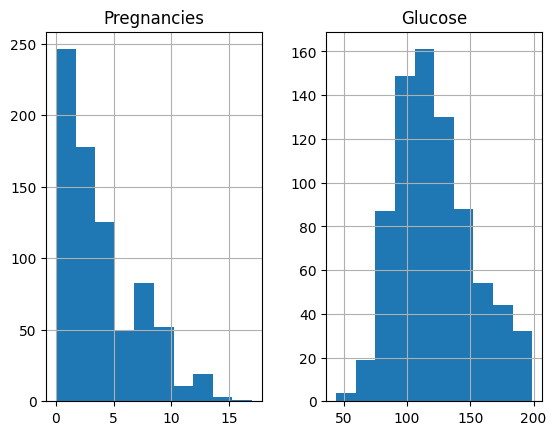

In [197]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
data[['Pregnancies', 'Glucose']].hist()

## Задание 11

Постройте круговую диаграмму для признака __Class__.

<Axes: ylabel='Share_of_every_class'>

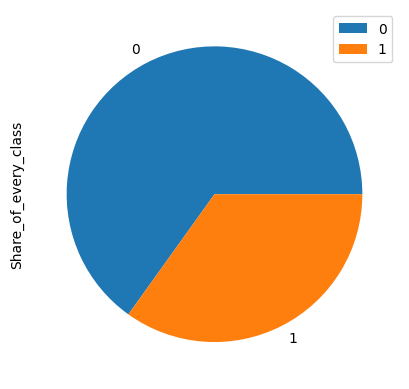

In [198]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
data['Share_of_every_class'] = 1
data_grouped = data.groupby(by='Class').count()
data_grouped.plot.pie(y = 'Share_of_every_class')

## Задание 12

Постройте распределение для признака __BMI__ и сравните его с нормальным (напишите вывод в новой markdown-ячейке под графиками)
Постройте нормальное распределение поверх графика.

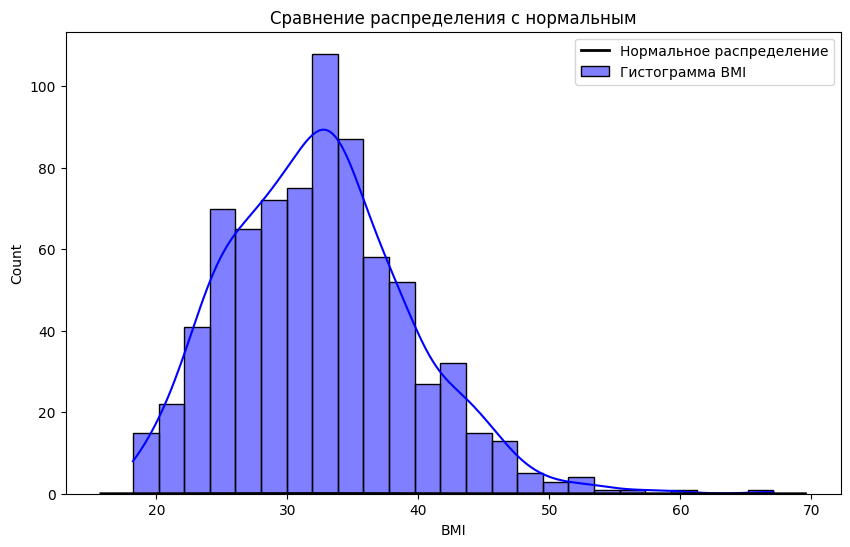

In [199]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
from scipy import stats
plt.figure(figsize=(10, 6))
#Гистограмма
sns.histplot(data['BMI'], kde=True, color='blue', label='Гистограмма BMI')
#Добавляем нормальное распределение для сравнения
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, np.mean(data['BMI']), np.std(data['BMI']))
plt.plot(x, p, 'k', linewidth=2, label='Нормальное распределение')
plt.title('Сравнение распределения с нормальным')
plt.legend()
plt.show()

Вывод: распределение близко к нормальному.

## Задание 13

Постройте следующий график: процент больных диабетом в зависимости от числа беременностей.

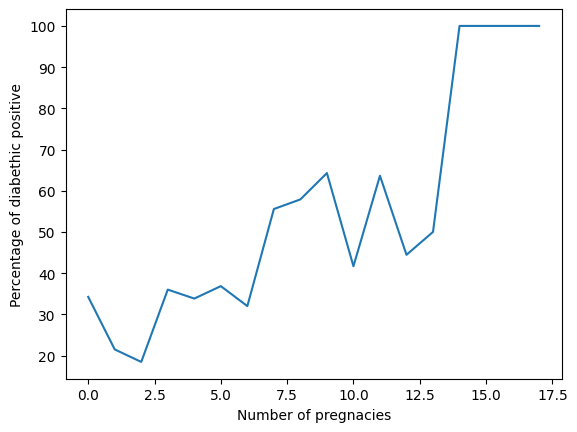

In [200]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
data_grouped = data.groupby(by = 'Pregnancies').agg({'Class':['sum', 'count']}).reset_index().set_axis(['Pregnancies', 'Class_sum', 'Class_count'], axis=1)
data_grouped['Percentage'] = data_grouped['Class_sum']/data_grouped['Class_count']*100
plt.plot(data_grouped['Pregnancies'], data_grouped['Percentage'])
plt.xlabel("Number of pregnacies")
plt.ylabel("Percentage of diabethic positive")
plt.show()

## Задание 14

Добавьте новый бинарный признак:

__wasPregnant__ $\in$ {0,1} - была женщина беременна (1) или нет (0)

In [201]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
data['wasPregnant'] = np.where(data['Pregnancies'] >= 1, 1,0)

## Задание 15

Сравните процент больных диабетом среди женщин, которые были беременны и не были.

In [202]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
data_grouped = data.groupby(by='wasPregnant').agg({'Class':['sum', 'count']}).reset_index().set_axis(['wasPregnant', 'sum', 'count'], axis=1)
data_grouped['Percent_of_positive'] = round(data_grouped['sum']/data_grouped['count']*100,1)
data_grouped

,wasPregnant,sum,count,Percent_of_positive
0,0,38,111,34.2
1,1,230,657,35.0


## Задание 16

Добавьте новый категориальный признак __bodyType__ на основе столбца BMI:

__BMI Categories:__
    
Underweight = <18.5

Normal weight = 18.5–24.9

Overweight = 25–29.9

Obesity = BMI of 30 or greater

Признак должен принимать значения Underweight, Normal weight, Overweight и Obesity.

In [203]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
def category_define(row):
    if row['BMI'] < 18.5:
        return 'Underweight'
    elif (row['BMI'] >= 18.5) and (row['BMI'] <= 24.9):
        return 'Normal weight'
    elif (row['BMI'] >= 25.0) and (row['BMI'] <= 29.9):
        return 'Overweight'
    else:
        return 'Obesity'
data['bodyType'] = data.apply(category_define, axis = 1)

## Задание 17

Будем считать "здоровыми" тех, у кого нормальный вес и кровяное давление. Какой процент "здоровых" женщин больны диабетом?

In [204]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
data_new = data[(data['bodyType'] == 'Normal weight') 
                & (data['BloodPressure'] <= 89)
                & (data['BloodPressure'] >= 80)]
percent = data_new['Class'].sum()/data_new['Class'].count()*100
print(f'{percent}% здоровых женщин больны диабетом')

10.0% здоровых женщин больны диабетом


# Часть II

Каждое задание в этой части оценивается в 1,15 баллов. Всего за выполнение этой части можно получить 3,45 балла.

In [206]:
response = requests.get(BABIES, verify=False)
data = pd.read_csv(io.StringIO(response.text))
print(data.head())

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'raw.githubusercontent.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


   Unnamed: 0       name sex  number  year
0           0       Mary   F    7065  1880
1           1       Anna   F    2604  1880
2           2       Emma   F    2003  1880
3           3  Elizabeth   F    1939  1880
4           4     Minnie   F    1746  1880


## Задание 1

Исследуйте набор данных `babies`. Ответьте на вопросы.

1. Какие годы включает датасет

2. Какое имя в датасете находится по индексом 121?

3. Cколько всего родилось детей по имени 'Aaron' за все время?

4. Насколько больше за все время родилось мальчиков чем девочек?

5. Cколько мальчиков родилось в 2010?

6. Сколько в датасете девочек по имени John?

In [211]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
#1. Какие годы включает датасет
data['year'].unique()

array(['F', 'M'], dtype=object)

In [208]:
#2. Какое имя в датасете находится по индексом 121?
data['name'][121]

'Ann'

In [209]:
#3. Cколько всего родилось детей по имени 'Aaron' за все время?
len(data[data['name'] == 'Aaron'])

212

In [214]:
#4. Насколько больше за все время родилось мальчиков чем девочек?
len(data[data['sex'] == 'M']) - len(data[data['sex'] == 'F']) 

-317186

In [223]:
#5. Cколько мальчиков родилось в 2010?
len(
    data[
        (data['sex'] == 'M') 
        & (data['year'] == 2010)
        ]
    )

14140

In [225]:
#6. Сколько в датасете девочек по имени John?
len(
    data[
        (data['sex'] == 'F') 
        & (data['name'] == 'John')
        ]
    )

131

## Задание 2

1. Сгруппируйте набор данных babies по году и полу и сохраните результаты в два новых датафрейма: baby_girls и baby_boys.

2. Создайте фигуру matplotlib с 3 графиками один под другим.

3. Постройте линейные графики. Первый график должен показывать тренд рождаемости для девочек, второй - для мальчиков, третий объединять их все вместе (с теми же цветами, что в индивидуальных графиках). Годы - x, количество детей - y.

4. Верхняя и правая границы графиков должны быть невидимы, к каждому графику должен быть заголовок, третий график должен содержать легенду, шкалы графиков должны быть подписаны.

5. Для шкалы количество должны быть установлены лимиты, чтобы она была одинакова на обоих графиках.

6. Кратко опишите тренды в ячейке markdown под графиками.

Если при группировке вы сделали год индексом, то можно обратиться к значениям этой переменной через аттрибут `.index`

In [248]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
#1. Сгруппируйте набор данных babies по году и полу и сохраните результаты в два новых датафрейма: baby_girls и baby_boys.
baby_all = data.groupby(by = ['year']).agg({'number':'sum'}).reset_index().set_axis(['year', 'number'], axis=1)
baby_boys = data[data['sex'] == 'M'].groupby(by = ['year', 'sex']).agg({'number':'sum'}).reset_index().set_axis(['year', 'sex', 'number'], axis=1)
baby_girls = data[data['sex'] == 'F'].groupby(by = ['year', 'sex']).agg({'number':'sum'}).reset_index().set_axis(['year', 'sex', 'number'], axis=1)

<function matplotlib.pyplot.show(close=None, block=None)>

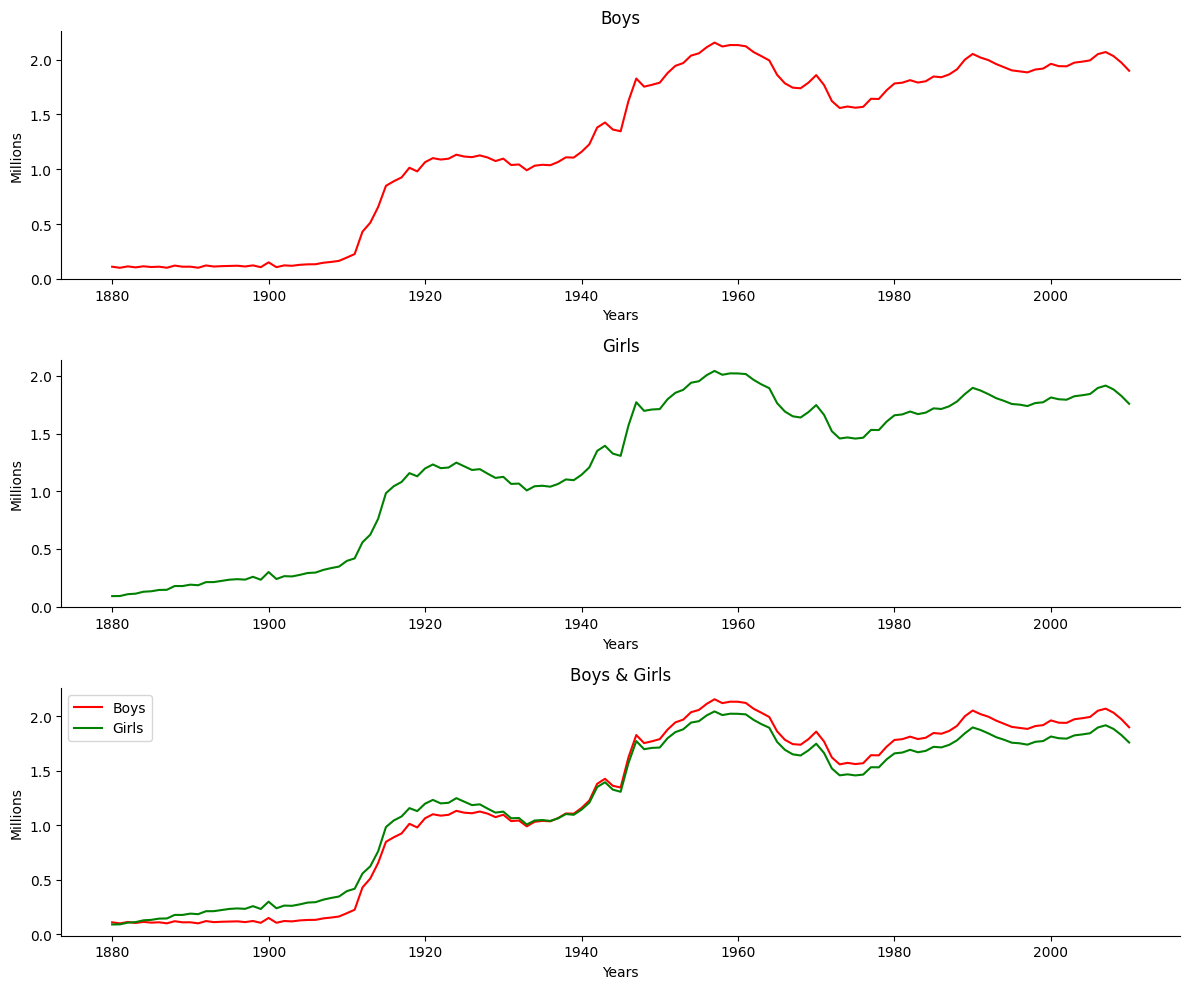

In [294]:
#3. Постройте линейные графики. Первый график должен показывать тренд рождаемости для девочек, второй - для мальчиков, третий объединять их все вместе (с теми же цветами, что в индивидуальных графиках). Годы - x, количество детей - y.
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

axes[0].plot(baby_boys['year'], baby_boys['number']/1000000, 'r-')
axes[0].set_title('Boys')
axes[0].set_xlabel('Years')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].set_ylabel('Millions')

axes[1].plot(baby_girls['year'], baby_girls['number']/1000000, 'g-')
axes[1].set_title('Girls')
axes[1].set_xlabel('Years')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].set_ylabel('Millions')

axes[2].plot(baby_boys['year'], baby_boys['number']/1000000, 'r-', label = 'Boys')
axes[2].plot(baby_girls['year'], baby_girls['number']/1000000, 'g-', label = 'Girls')
axes[2].set_title('Boys & Girls')
axes[2].set_xlabel('Years')
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)
axes[2].set_ylabel('Millions')
axes[2].legend() 

plt.tight_layout()
plt.show

Основные тренды:

Бурный рост в 1910-х и второй половине 1940-х

Просадки рождаемости в 1930-40-х и 1970-х

До 1940-х больше рождалось девочек, потом - мальчиков

Замедление рота рождаемости с 1980


## Задание 3

1. Сгруппируйте нужным способом датафрейм babies и найдите 4 самых популярных имени за всю историю (2 женских и 2 мужских).

2. Для каждого найденного имени создайте новый датафрейм вида babies_alisa и сохраните в него данные, сколько детей с таким именем рождалось каждый год.

3. Создайте фигуру matplotlib с 4 горизонтальными графиками один под другим.

4. Постройте 4 линейных графика - тренд для каждого имени за все время.

5. Каждый график должен содержать легенду, один общий заголовок, шкалы графиков должны быть подписаны.

6. Для шкалы количество должны быть установлены лимиты, чтобы она была одинакова на обоих графиках.

7. Опишите тренды в ячейке markdown под графиками.

In [337]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
data_grouped = data.groupby(by = ['sex', 'name'])['number'].sum().reset_index()
data_grouped['rank_name'] = data_grouped.groupby('sex')['number'].rank(method = 'first', ascending = False).astype(int)
names_dict = dict(zip(data_grouped[data_grouped['rank_name'] < 3]['name'], data_grouped[data_grouped['rank_name'] < 3]['sex']))
dfs = []
for i,v in names_dict.items():
    data_name = f'babies_{i.lower()}'
    dfs.append(f'babies_{i.lower()}')
    globals()[data_name] = data[(data['name'] == i) &((data['sex'] == v))]
dfs

['babies_mary', 'babies_patricia', 'babies_james', 'babies_john']

In [338]:
names_dict

{'Mary': 'F', 'Patricia': 'F', 'James': 'M', 'John': 'M'}

In [339]:
babies_mary

,Unnamed: 0,name,sex,number,year
0,0,Mary,F,7065,1880
2000,0,Mary,F,6919,1881
3935,0,Mary,F,8149,1882
6062,0,Mary,F,8012,1883
8146,0,Mary,F,9217,1884
...,...,...,...,...,...
1518496,80,Mary,F,4073,2006
1552547,92,Mary,F,3665,2007
1587434,96,Mary,F,3478,2008
1622445,101,Mary,F,3132,2009


<function matplotlib.pyplot.show(close=None, block=None)>

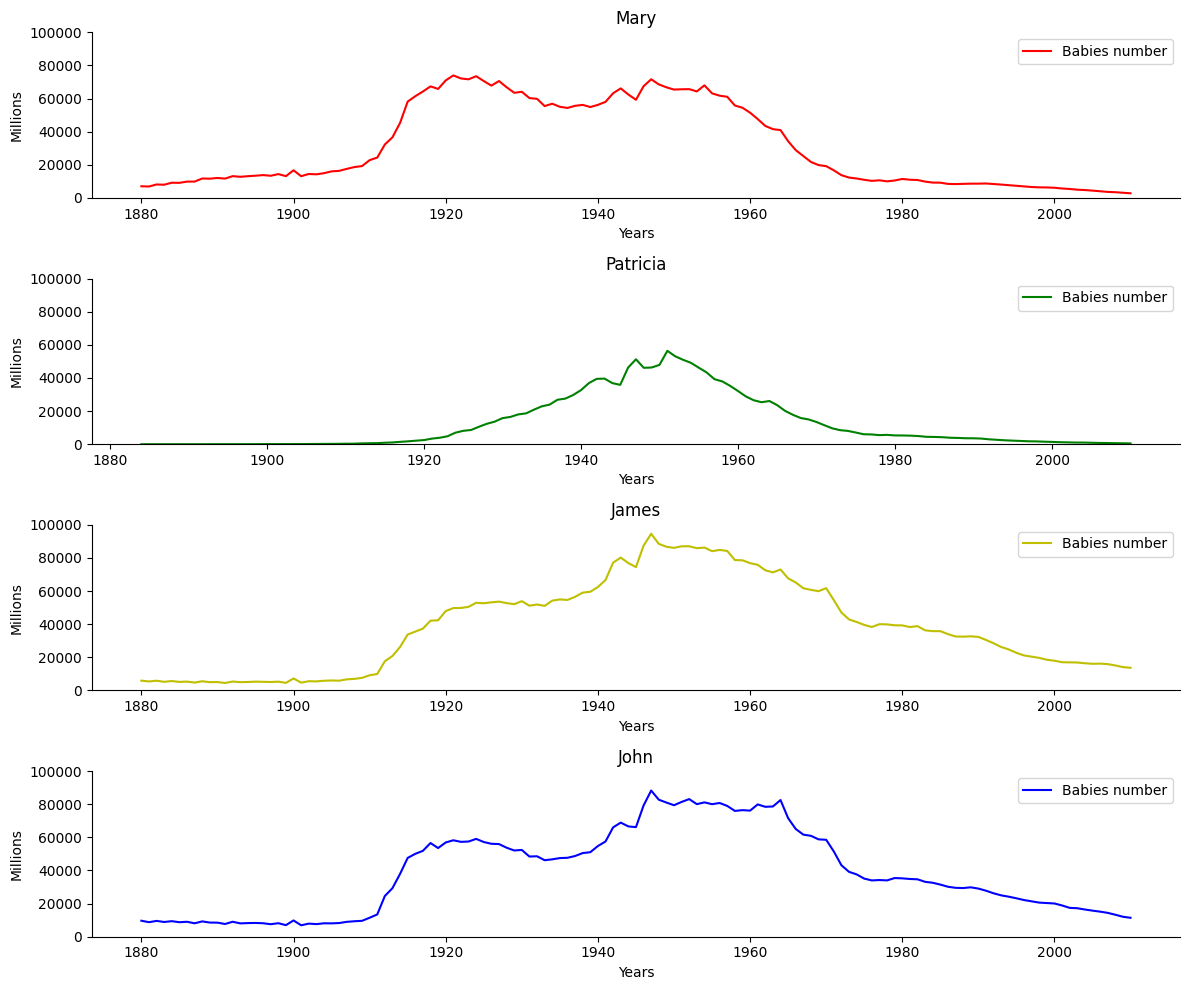

In [354]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10))

axes[0].plot(babies_mary['year'], babies_mary['number'], 'r-', label = 'Babies number')
axes[0].set_title('Mary')
axes[0].set_xlabel('Years')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].set_ylabel('Millions')
axes[0].legend()
axes[0].set_ylim(0,100000)

axes[1].plot(babies_patricia['year'], babies_patricia['number'], 'g-', label = 'Babies number')
axes[1].set_title('Patricia')
axes[1].set_xlabel('Years')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].set_ylabel('Millions')
axes[1].legend()
axes[1].set_ylim(0,100000)

axes[2].plot(babies_james['year'], babies_james['number'], 'y-', label = 'Babies number')
axes[2].set_title('James')
axes[2].set_xlabel('Years')
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)
axes[2].set_ylabel('Millions')
axes[2].legend()
axes[2].set_ylim(0,100000)

axes[3].plot(babies_john['year'], babies_john['number'], 'b-', label = 'Babies number')
axes[3].set_title('John')
axes[3].set_xlabel('Years')
axes[3].spines['top'].set_visible(False)
axes[3].spines['right'].set_visible(False)
axes[3].set_ylabel('Millions')
axes[3].legend() 
axes[3].set_ylim(0,100000)
plt.tight_layout()
plt.show

Для всех имен кроме Patricia характерен резкий рост в 1910-х годах. Имя Patricia начинает бурно расти в 1920-х годах

Начиная примерно со второй половины 1940-х гг для всех имен начинается снижение кол-во детей с такими имена

Для имени Мэри максимальное кол-во детей было в 1920-х. Для остальных имен - 40-50-е гг.

## Часть III

Каждое задание в этой части оценивается в 0,2 балла. Всего за выполнение этой части можно получить 4 балла.

Вам предлагается проанализировать датасет с Data - вакансиями.  
Скачайте его https://disk.yandex.ru/d/QUa3pCKVk48cAQ и считайте с помощью `pd.read_csv`.


In [355]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*
data = pd.read_csv('vacancies.csv')
data

,Unnamed: 0,position_name,employer_name,area,experience,schedule,employment,professional_roles,salary,description,key_skills
0,0,Data Scientist Авито,Changellenge,Москва,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 255000, 'to': 490000, 'currency': 'RU...",<p>В наших командах разрабатывают эффективные ...,[]
1,1,Data analyst,Публичная Компания «Freedom Finance Global PLC»,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,"BI-аналитик, аналитик данных","{'from': 800000, 'to': 'null', 'currency': 'KZ...",<p><strong>Обязанности</strong></p><ul><li>Изв...,[]
2,2,Data Engineer/Data Analyst,IMANTECH,Ташкент,Нет опыта,Гибкий график,Полная занятость,"BI-аналитик, аналитик данных",NaN,<p><strong>About Us:</strong> Welcome to <stro...,"['SQL', 'Визуализация данных', 'Python', 'Powe..."
3,3,Стажер в направление Big Data,T2,Москва,Нет опыта,Полный день,Полная занятость,"BI-аналитик, аналитик данных",NaN,<strong>Что нужно делать:</strong> <ul> <li>Со...,[]
4,4,Data Marketing Manager / Маркетолог по анализу...,Procter & Gamble,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 950000, 'to': 'null', 'currency': 'KZ...",<p><strong>Найм в ТОО «Проктер энд Гэмбл Казах...,"['Английский язык', 'Аналитический склад ума']"
...,...,...,...,...,...,...,...,...,...,...,...
1522,1522,Senior Data Scientist в b2c направление,HeadHunter,Москва,От 3 до 6 лет,Гибкий график,Полная занятость,"Программист, разработчик",NaN,<p>Наша команда работает с соискательской функ...,"['Python', 'Machine Learning', 'SQL', 'PyTorch..."
1523,1523,Data analyst (Senior),Иви,Москва,От 3 до 6 лет,Полный день,Полная занятость,"BI-аналитик, аналитик данных",NaN,<p><strong>Иви — один из лидеров рынка онлайн-...,[]
1524,1524,Senior Data Analyst,Autodoc Group (Автодок Казахстан),Алматы,От 3 до 6 лет,Полный день,Полная занятость,Продуктовый аналитик,NaN,<p>Company Description</p> <p>AUTODOC is a tec...,[]
1525,1525,TeamLead Data Engineer,HeadHunter,Москва,От 3 до 6 лет,Полный день,Полная занятость,"Программист, разработчик",NaN,"<p><strong>Привет,</strong> <strong>на связи к...","['Python', 'Apache Airflow', 'Apache Cassandra..."


1. Выведите первые 5 и последние 5 строк датасета. Примените к датасету методы `info` и `describe`. Сколько в датасете строк и столбцов?

In [ ]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。

In [359]:
data.head()

,Unnamed: 0,position_name,employer_name,area,experience,schedule,employment,professional_roles,salary,description,key_skills
0,0,Data Scientist Авито,Changellenge,Москва,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 255000, 'to': 490000, 'currency': 'RU...",<p>В наших командах разрабатывают эффективные ...,[]
1,1,Data analyst,Публичная Компания «Freedom Finance Global PLC»,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,"BI-аналитик, аналитик данных","{'from': 800000, 'to': 'null', 'currency': 'KZ...",<p><strong>Обязанности</strong></p><ul><li>Изв...,[]
2,2,Data Engineer/Data Analyst,IMANTECH,Ташкент,Нет опыта,Гибкий график,Полная занятость,"BI-аналитик, аналитик данных",NaN,<p><strong>About Us:</strong> Welcome to <stro...,"['SQL', 'Визуализация данных', 'Python', 'Powe..."
3,3,Стажер в направление Big Data,T2,Москва,Нет опыта,Полный день,Полная занятость,"BI-аналитик, аналитик данных",NaN,<strong>Что нужно делать:</strong> <ul> <li>Со...,[]
4,4,Data Marketing Manager / Маркетолог по анализу...,Procter & Gamble,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 950000, 'to': 'null', 'currency': 'KZ...",<p><strong>Найм в ТОО «Проктер энд Гэмбл Казах...,"['Английский язык', 'Аналитический склад ума']"


In [360]:
data.tail()

,Unnamed: 0,position_name,employer_name,area,experience,schedule,employment,professional_roles,salary,description,key_skills
1522,1522,Senior Data Scientist в b2c направление,HeadHunter,Москва,От 3 до 6 лет,Гибкий график,Полная занятость,"Программист, разработчик",NaN,<p>Наша команда работает с соискательской функ...,"['Python', 'Machine Learning', 'SQL', 'PyTorch..."
1523,1523,Data analyst (Senior),Иви,Москва,От 3 до 6 лет,Полный день,Полная занятость,"BI-аналитик, аналитик данных",NaN,<p><strong>Иви — один из лидеров рынка онлайн-...,[]
1524,1524,Senior Data Analyst,Autodoc Group (Автодок Казахстан),Алматы,От 3 до 6 лет,Полный день,Полная занятость,Продуктовый аналитик,NaN,<p>Company Description</p> <p>AUTODOC is a tec...,[]
1525,1525,TeamLead Data Engineer,HeadHunter,Москва,От 3 до 6 лет,Полный день,Полная занятость,"Программист, разработчик",NaN,"<p><strong>Привет,</strong> <strong>на связи к...","['Python', 'Apache Airflow', 'Apache Cassandra..."
1526,1526,Senior Python Developer (Data Platform),Mindbox,Москва,От 3 до 6 лет,Гибкий график,Полная занятость,"Программист, разработчик",NaN,<p><strong>Mindbox</strong> — крупнейшая в Рос...,"['Python', 'PySpark', 'Airflow', 'Kafka', 'Del..."


In [ ]:
data.info()

In [ ]:
data.describe()

In [364]:
print(f'В файле vacancies.csv {len(data)} строк и {len(list(data.columns))} столбцов')

В файле vacancies.csv 1527 строк и 11 столбцов


2. Есть ли в датасете пропуски?

In [368]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
data.isnull()print(f'В файле vacancies.csv есть пропуски')

,Unnamed: 0,position_name,employer_name,area,experience,schedule,employment,professional_roles,salary,description,key_skills
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,True,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
1522,False,False,False,False,False,False,False,False,True,False,False
1523,False,False,False,False,False,False,False,False,True,False,False
1524,False,False,False,False,False,False,False,False,True,False,False
1525,False,False,False,False,False,False,False,False,True,False,False


In [369]:
print(f'В файле vacancies.csv есть пропуски')

В файле vacancies.csv есть пропуски


3. Есть в датасете полные дубли? Если да, удалите их (метод drop_duplicates).

In [373]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
if data.duplicated().any():
    data.drop_duplicates()

4. Сколько уникальных значений у переменной professional_roles?

In [377]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
print(f'В столбце professional_roles файла vacancies.csv {len(data['professional_roles'].unique())} уникальных значений')

В столбце professional_roles файла vacancies.csv 36 уникальных значений


5. Сколько в датасете вакансий, не требующих опыта?

In [384]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
print(f'В файле vacancies.csv {len(data['professional_roles'])} вакансий, не требующих опыта')

В файле vacancies.csv 1527 вакансий, не требующих опыта


6. Какое среднее количество навыков в вакансии? (переменная key_skills)

In [406]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。ёв
data.head()
data['number_of_skills'] = data['key_skills'].apply(lambda x: len(x.split(',')) if x != '[]' else 0  )
print(f'Среднее необходимое кол-во навыков: {round(data['number_of_skills'].mean())}')

Среднее необходимое кол-во навыков: 4


7. Какие валюты (ключ currency в поле salary) используются для заработной платы? Создайте столбец currency.  
*Подсказка. Как вариант, можете воспользоваться функцией eval, которая исполняет код, написанный в строке. Для проверки на NaN можете использовать pd.isnull()*

In [ ]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。

In [416]:
import ast
import json
data['currency'] = data['salary'].apply(lambda x: ast.literal_eval(x)['currency'] if pd.notna(x) else 'Не указано')
print(f'Используются следующие валюты: {data['currency'].unique()}')

Используются следующие валюты: ['RUR' 'KZT' 'Не указано' 'UZS' 'USD' 'EUR' 'BYR']


8. Какая компания лидирует по количеству вакансий?

In [439]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*
data_grouped = data.groupby(by = 'employer_name').agg({'position_name':'count'}).sort_values(by = 'position_name', ascending = False).reset_index()
print(f'Работодатель с максимальным кол-вом вакансий: {data_grouped['employer_name'][0]}')

Работодатель с максимальным кол-вом вакансий: СБЕР


In [438]:
data_grouped

,employer_name,position_name
0,СБЕР,146
1,Aston,70
2,Т-Банк,56
3,EPAM Uzbekistan,46
4,Газпромбанк,30
...,...,...
519,X5 Digital,1
520,Workle Pro,1
521,WhoIsBlogger (WIB),1
522,Arbuz Group (Арбуз Груп),1


9.  Какая компания лидирует по количеству вакансий с указанием заработной платы?

In [440]:
data

,Unnamed: 0,position_name,employer_name,area,experience,schedule,employment,professional_roles,salary,description,key_skills,number_of_skills,currency
0,0,Data Scientist Авито,Changellenge,Москва,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 255000, 'to': 490000, 'currency': 'RU...",<p>В наших командах разрабатывают эффективные ...,[],0,RUR
1,1,Data analyst,Публичная Компания «Freedom Finance Global PLC»,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,"BI-аналитик, аналитик данных","{'from': 800000, 'to': 'null', 'currency': 'KZ...",<p><strong>Обязанности</strong></p><ul><li>Изв...,[],0,KZT
2,2,Data Engineer/Data Analyst,IMANTECH,Ташкент,Нет опыта,Гибкий график,Полная занятость,"BI-аналитик, аналитик данных",NaN,<p><strong>About Us:</strong> Welcome to <stro...,"['SQL', 'Визуализация данных', 'Python', 'Powe...",11,Не указано
3,3,Стажер в направление Big Data,T2,Москва,Нет опыта,Полный день,Полная занятость,"BI-аналитик, аналитик данных",NaN,<strong>Что нужно делать:</strong> <ul> <li>Со...,[],0,Не указано
4,4,Data Marketing Manager / Маркетолог по анализу...,Procter & Gamble,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 950000, 'to': 'null', 'currency': 'KZ...",<p><strong>Найм в ТОО «Проктер энд Гэмбл Казах...,"['Английский язык', 'Аналитический склад ума']",2,KZT
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1522,1522,Senior Data Scientist в b2c направление,HeadHunter,Москва,От 3 до 6 лет,Гибкий график,Полная занятость,"Программист, разработчик",NaN,<p>Наша команда работает с соискательской функ...,"['Python', 'Machine Learning', 'SQL', 'PyTorch...",19,Не указано
1523,1523,Data analyst (Senior),Иви,Москва,От 3 до 6 лет,Полный день,Полная занятость,"BI-аналитик, аналитик данных",NaN,<p><strong>Иви — один из лидеров рынка онлайн-...,[],0,Не указано
1524,1524,Senior Data Analyst,Autodoc Group (Автодок Казахстан),Алматы,От 3 до 6 лет,Полный день,Полная занятость,Продуктовый аналитик,NaN,<p>Company Description</p> <p>AUTODOC is a tec...,[],0,Не указано
1525,1525,TeamLead Data Engineer,HeadHunter,Москва,От 3 до 6 лет,Полный день,Полная занятость,"Программист, разработчик",NaN,"<p><strong>Привет,</strong> <strong>на связи к...","['Python', 'Apache Airflow', 'Apache Cassandra...",9,Не указано


In [563]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*
data_new = data[data['salary'].isnull() == False]
data_grouped = data_new.groupby(by = 'employer_name').agg({'position_name':'count'}).sort_values(by = 'position_name', ascending = False).reset_index()
print(f'Работодатель с максимальным кол-вом вакансий с указанной ЗП: {data_grouped['employer_name'][0]}')

Работодатель с максимальным кол-вом вакансий с указанной ЗП: Aston


In [524]:
data['salary'][29]

"{'from': 70000, 'to': 'null', 'currency': 'RUR', 'gross': False}"

10. Создайте столбец salary_num. Рассчитайте его, используя столбец salary. Если в это столбце указана вилка зарплаты, используйте среднее значение между from и to. Если указано только одно из значений (from или to, используйте его) **(2)**

In [535]:
def salary_extract(d):
    if pd.isna(d):
        return 0
    else: 
        x = ast.literal_eval(d)
        if 'from' not in x or str(x.get('from')).isdigit() == False:
            x['from'] = 0
        if 'to' not in x or str(x.get('to')).isdigit() == False:
            x['to'] = 0
        y = (x.get('from') + x.get('to'))/2
    return y

In [536]:
data['salary_num'] = data['salary'].apply(salary_extract)

11. Какая средняя заработная плата среди вакансий в рублях? А медианная заработная плата?  

In [537]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
print(f'Средняя ЗП в рублях: {round(data[data['currency'] == 'RUR']['salary_num'].mean())}')
print(f'Медианная ЗП в рублях: {round(data[data['currency'] == 'RUR']['salary_num'].median())}')

Средняя ЗП в рублях: 154312
Медианная ЗП в рублях: 120000


12. Создайте столбец is_python_requirement, который принимает значение 1, если в key_skills присутствует python (учитывайте написание в любом регистре, а также вхождения подстроки python.).  Какой процент вакансий требует знания python?

In [557]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
def is_python(row):
    if pd.isna(row):
        return 0
    else:
        if 'python' in row.lower():
            return 1
        else:
            return 0

In [558]:
data['is_python_requirement'] = data['key_skills'].apply(is_python)

13. Сгруппируйте по столбцам experience, schedule, employment, is_python_requirement (сразу по четырем столбцам). Найдите по каждой группе:
- количество опубликованных вакансий
- количество компаний, которые опубликовали вакансии
- среднюю заработную плату среди вакансий с указанием зарплаты в рублях


In [581]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
data_grouped = data.groupby(by=['experience', 'schedule', 'employment', 'is_python_requirement']).\
    agg(vacancies = pd.NamedAgg(column = 'position_name', aggfunc = 'count'),
        companies = pd.NamedAgg(column = 'employer_name', aggfunc = 'nunique'),
        avg_rur_salary = pd.NamedAgg(column = 'salary_num', aggfunc = lambda x: x[data.loc[x.index, 'currency'] == 'RUR'].mean())                    
       ).reset_index()
data_grouped

,experience,schedule,employment,is_python_requirement,vacancies,companies,avg_rur_salary
0,Более 6 лет,Гибкий график,Полная занятость,0,4,2,NaN
1,Более 6 лет,Гибкий график,Частичная занятость,0,1,1,NaN
2,Более 6 лет,Полный день,Полная занятость,0,49,30,203000.000000
3,Более 6 лет,Полный день,Полная занятость,1,10,9,NaN
4,Более 6 лет,Удаленная работа,Полная занятость,0,11,7,225000.000000
5,Более 6 лет,Удаленная работа,Полная занятость,1,12,10,155000.000000
6,Нет опыта,Гибкий график,Полная занятость,1,2,2,225000.000000
7,Нет опыта,Гибкий график,Стажировка,1,3,1,NaN
8,Нет опыта,Полный день,Полная занятость,0,26,17,48785.714286
9,Нет опыта,Полный день,Полная занятость,1,55,6,75714.285714


14. Создайте столбец count_skills. В нём должна быть длина списка, который находит в столбце key_skills. Обратите внимание, что изначально столбец key_skills - строка, например, '[]' Подумайте, как превратить её в список и посчитать его длину.  

In [609]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
import re
data['count_skills'] = data['key_skills'].apply(lambda x: len(re.sub('[]"]', '', x).split(',')) if (x != '[]' or pd.isna(x)) else 0)
data

,Unnamed: 0,position_name,employer_name,area,experience,schedule,employment,professional_roles,salary,description,key_skills,number_of_skills,currency,salary_num,is_python_requirement,count_skills
0,0,Data Scientist Авито,Changellenge,Москва,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 255000, 'to': 490000, 'currency': 'RU...",<p>В наших командах разрабатывают эффективные ...,[],0,RUR,372500.0,0,0
1,1,Data analyst,Публичная Компания «Freedom Finance Global PLC»,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,"BI-аналитик, аналитик данных","{'from': 800000, 'to': 'null', 'currency': 'KZ...",<p><strong>Обязанности</strong></p><ul><li>Изв...,[],0,KZT,400000.0,0,0
2,2,Data Engineer/Data Analyst,IMANTECH,Ташкент,Нет опыта,Гибкий график,Полная занятость,"BI-аналитик, аналитик данных",NaN,<p><strong>About Us:</strong> Welcome to <stro...,"['SQL', 'Визуализация данных', 'Python', 'Powe...",11,Не указано,0.0,1,11
3,3,Стажер в направление Big Data,T2,Москва,Нет опыта,Полный день,Полная занятость,"BI-аналитик, аналитик данных",NaN,<strong>Что нужно делать:</strong> <ul> <li>Со...,[],0,Не указано,0.0,0,0
4,4,Data Marketing Manager / Маркетолог по анализу...,Procter & Gamble,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 950000, 'to': 'null', 'currency': 'KZ...",<p><strong>Найм в ТОО «Проктер энд Гэмбл Казах...,"['Английский язык', 'Аналитический склад ума']",2,KZT,475000.0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1522,1522,Senior Data Scientist в b2c направление,HeadHunter,Москва,От 3 до 6 лет,Гибкий график,Полная занятость,"Программист, разработчик",NaN,<p>Наша команда работает с соискательской функ...,"['Python', 'Machine Learning', 'SQL', 'PyTorch...",19,Не указано,0.0,1,19
1523,1523,Data analyst (Senior),Иви,Москва,От 3 до 6 лет,Полный день,Полная занятость,"BI-аналитик, аналитик данных",NaN,<p><strong>Иви — один из лидеров рынка онлайн-...,[],0,Не указано,0.0,0,0
1524,1524,Senior Data Analyst,Autodoc Group (Автодок Казахстан),Алматы,От 3 до 6 лет,Полный день,Полная занятость,Продуктовый аналитик,NaN,<p>Company Description</p> <p>AUTODOC is a tec...,[],0,Не указано,0.0,0,0
1525,1525,TeamLead Data Engineer,HeadHunter,Москва,От 3 до 6 лет,Полный день,Полная занятость,"Программист, разработчик",NaN,"<p><strong>Привет,</strong> <strong>на связи к...","['Python', 'Apache Airflow', 'Apache Cassandra...",9,Не указано,0.0,1,9


15. Создайте столбец len_descr, в котором должна быть длина описания (description) в символах без учета html тегов ("<...>"). Напишите для этого функцию get_len_descr.  Можете использовать регулярные выражения.
То есть, ваш код может выглядеть, например, так:

In [613]:
import re

def get_len_descr(descr):
  clean_descr = re.sub('<[^>]*>', '', descr) # ваш код
  len_descr = len(clean_descr)
  return len_descr

data['len_descr'] = data['description'].apply(get_len_descr)

16. Постройте таблицу корреляций с тремя переменными: salary_num, len_descr, count_skills.  

In [626]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
from scipy import stats
new_data = data[['salary_num', 'len_descr', 'count_skills']]
matrix = new_data.corr()
matrix

,salary_num,len_descr,count_skills
salary_num,1.000000,-0.013917,0.076534
len_descr,-0.013917,1.000000,0.126049
count_skills,0.076534,0.126049,1.000000


17. Постройте тепловую карту из таблицы из предыдущего пункта.

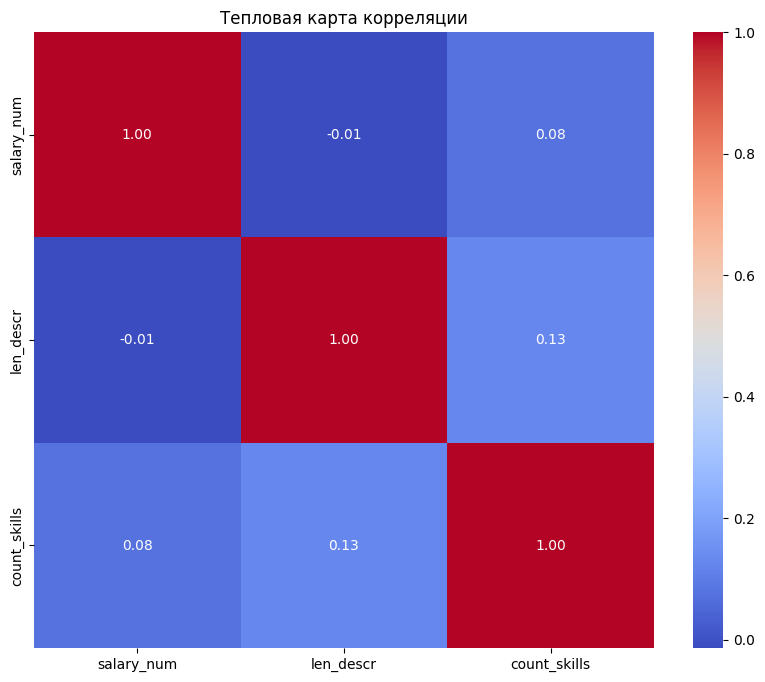

In [628]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
plt.figure(figsize=(10, 8)) # Размер графика
sns.heatmap(matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Тепловая карта корреляции')
plt.show()

18. Какие скиллы чаще всего требуются? Выведите топ-10 требуемых скиллов.

In [688]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
skills_list_raw = data['key_skills'].tolist()
skills_list_clean = []
for i in skills_list_raw:
    cleaned_list = re.sub(r"[\[\]']", "", i).split(', ')
    if cleaned_list != ['']:
        skills_list_clean.append(cleaned_list)
dict_skills = {}
for i in skills_list_clean:
    for j in i:
        j = j.lower()
        if j not in dict_skills:
            dict_skills[j] = 0
        else:
            dict_skills[j] +=1
dict_skills_sorted = sorted(dict_skills.items(), key=lambda x: x[1], reverse=True)
top_10 = dict(dict_skills_sorted[:10])
top_10

{'python': 632,
 'sql': 573,
 'etl': 153,
 'big data': 145,
 'hadoop': 118,
 'postgresql': 112,
 'dwh': 110,
 'clickhouse': 101,
 'английский язык': 92,
 'математический анализ': 89}

19. Постройте гистограмму распределения зарплаты среди вакансий в рублях.  

array([[<Axes: title={'center': 'salary_num'}>]], dtype=object)

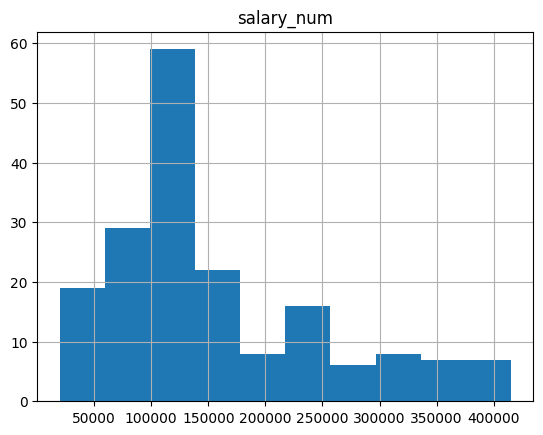

In [692]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
data_new = data[data['currency'] == 'RUR']
data_new.hist('salary_num')

20. Постройте boxplot зарплаты (среди вакансий в рублях) с группировкой по полю experience

<Axes: title={'center': 'salary_num'}, xlabel='experience'>

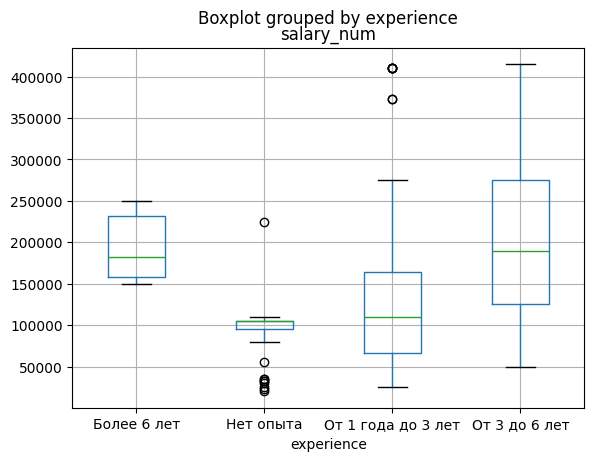

In [693]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。
data_new.boxplot(column = 'salary_num', by = 'experience')